<a href="https://colab.research.google.com/github/shardeep-x/agentic-ai-and-gen-ai/blob/foundation_of_gen_ai_llm/Classification_Breast_Cancer_Prediction_and_DIY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Prediction using scikit-learn #

![breast cancer detection image](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-024-57740-5/MediaObjects/41598_2024_57740_Fig1_HTML.png)

Problem - Breast cancer prediction is a binary classification problem where the goal is to determine whether a tumor is malignant (cancerous) or benign (non-cancerous) based on measurable characteristics of cell nuclei obtained from medical imaging or biopsies.


sklearn datasets - https://scikit-learn.org/stable/api/sklearn.datasets.html

## Import required libraries ##

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Resources

This section explains the libraries imported for our machine learning task.

*   **`numpy`**: Fundamental package for numerical computation in Python. It's used for efficient array operations. [NumPy Documentation](https://numpy.org/doc/stable/)
*   **`matplotlib.pyplot`**: A plotting library used to create static, animated, and interactive visualizations in Python. [Matplotlib Documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html)
*   **`sklearn.datasets.load_breast_cancer`**: Used to load the Breast Cancer Wisconsin (Diagnostic) dataset, a classic dataset for binary classification. [Scikit-learn Breast Cancer Dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)
*   **`sklearn.model_selection.train_test_split`**: A utility to split arrays or matrices into random train and test subsets. This is crucial for evaluating model performance on unseen data. [train_test_split Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
*   **`sklearn.preprocessing.StandardScaler`**: Scales features to a standard normal distribution (mean=0, variance=1). This is important for many machine learning algorithms, especially distance-based ones. [StandardScaler Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

**Pictorial Representation**: [Machine Learning Workflow Diagram](https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/Data_analysis_process_v2.svg/1200px-Data_analysis_process_v2.svg.png)

## Loading the breast cancer data ##

In [18]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

print("Shape:", X.shape)

Shape: (569, 30)


## Resources

This code block loads the Breast Cancer Wisconsin (Diagnostic) dataset. It's a common dataset for classification tasks.

*   **`data = load_breast_cancer()`**: Loads the dataset object, which contains both the features (`X`) and the target variable (`y`).
*   **`X = data.data`**: Extracts the feature matrix. Each row represents a patient, and each column is a measured feature of their tumor (e.g., radius, texture, perimeter). There are 30 features.
*   **`y = data.target`**: Extracts the target vector. This is the label we want to predict: `0` for malignant (cancerous) and `1` for benign (non-cancerous).
*   **`print("Shape:", X.shape)`**: Displays the dimensions of the feature matrix. The output `(569, 30)` means there are 569 samples (patients) and 30 features per sample.

**Understanding the Data**: [UCI Machine Learning Repository: Breast Cancer Wisconsin (Diagnostic) Data Set](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic))

**Pictorial Representation**: [Example of a Feature Matrix (Conceptual)](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Matrix_with_features.svg/640px-Matrix_with_features.svg.png)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Resources

This crucial step prepares the data for model training and evaluation.

*   **`X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`**:
    *   **Purpose**: Splits the dataset into training and testing sets. This ensures that the model is trained on one subset of data and evaluated on a completely unseen subset, giving an unbiased estimate of its performance.
    *   **`test_size=0.2`**: Specifies that 20% of the data will be used for testing, and the remaining 80% for training.
    *   **`random_state=42`**: Ensures reproducibility. If you run this code multiple times, you'll get the same split every time.
    *   **Output**: `X_train` (features for training), `X_test` (features for testing), `y_train` (labels for training), `y_test` (labels for testing).
*   **`scaler = StandardScaler()`**: Initializes a `StandardScaler` object. This scaler will transform features by removing the mean and scaling to unit variance.
*   **`X_train = scaler.fit_transform(X_train)`**:
    *   **`fit_transform`**: Calculates the mean and standard deviation of `X_train` (`fit`) and then applies the scaling transformation (`transform`) to `X_train`.
    *   **Importance**: Scaling is vital for many algorithms (like Logistic Regression, SVM, KNN) that are sensitive to the magnitude of features. It prevents features with larger values from dominating the learning process.
*   **`X_test = scaler.transform(X_test)`**:
    *   **`transform`**: Applies the *same* scaling (using the mean and standard deviation learned from `X_train`) to `X_test`. It's crucial *not* to use `fit_transform` on `X_test` to prevent data leakage from the test set into the training process.

**Why Split Data?**: [Towards Data Science - Why we split data into train and test](https://towardsdatascience.com/train-test-split-and-cross-validation-in-python-80b6151f1577)

**Why Feature Scaling?**: [GeeksforGeeks - Feature Scaling](https://www.geeksforgeeks.org/feature-scaling-and-normalization/)

**Pictorial Representation**: [Train/Test Split Diagram](https://scikit-learn.org/stable/_images/sphx_glr_plot_train_test_split_001.png)

## Part-1 : Classification using Logistic Regression ##

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

## Resources

This cell performs predictions using the trained Logistic Regression model.

*   **`y_pred = model.predict(X_test)`**:
    *   **Purpose**: After training the `LogisticRegression` model on `X_train` and `y_train`, we use its `predict` method to generate class labels for the unseen `X_test` data.
    *   **`X_test`**: The scaled feature set that the model has not seen during training.
    *   **`y_pred`**: The output of this function is an array containing the predicted class (0 or 1) for each sample in `X_test`. This array (`y_pred`) will be compared against the actual `y_test` labels to evaluate the model's performance.

**How Logistic Regression Predicts**: The model calculates the probability of each sample belonging to the positive class (1) using the logistic (sigmoid) function. If this probability exceeds a certain threshold (usually 0.5), it predicts class 1; otherwise, it predicts class 0. [Sigmoid Function Visual](https://upload.wikimedia.org/wikipedia/commons/thumb/8/88/Logistic-curve.svg/640px-Logistic-curve.svg.png)

**Scikit-learn `predict` method**: [Scikit-learn `predict` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict)

In [24]:
y_pred = model.predict(X_test)

## Resources

This section evaluates the performance of the Logistic Regression model using key classification metrics.

*   **`accuracy_score(y_test, y_pred)`**: Measures the overall correctness of the model. It's the ratio of correctly predicted instances to the total number of instances. **Formula**: (TP + TN) / (TP + TN + FP + FN).
    *   **When to use**: Good for balanced datasets. Less informative for imbalanced datasets.
    *   [Accuracy Score Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)

*   **`confusion_matrix(y_test, y_pred)`**: A table that describes the performance of a classification model on a set of test data for which the true values are known. It shows:
    *   **True Positives (TP)**: Correctly predicted positive class.
    *   **True Negatives (TN)**: Correctly predicted negative class.
    *   **False Positives (FP)**: Incorrectly predicted positive class (Type I error).
    *   **False Negatives (FN)**: Incorrectly predicted negative class (Type II error).
    *   [Confusion Matrix Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
    *   **Pictorial Representation**: [What is a Confusion Matrix?](https://www.v7labs.com/blog/confusion-matrix-guide#what-is-a-confusion-matrix-and-what-does-it-tell-you)

*   **`classification_report(y_test, y_pred)`**: Provides a text report showing the main classification metrics for each class, including Precision, Recall, F1-score, and Support.
    *   **Precision**: Out of all predicted positives, how many were actually positive? **Formula**: TP / (TP + FP).
    *   **Recall (Sensitivity)**: Out of all actual positives, how many were correctly predicted as positive? **Formula**: TP / (TP + FN).
    *   **F1-score**: The harmonic mean of Precision and Recall. It's a balanced measure, especially useful when there's an uneven class distribution. **Formula**: 2 * (Precision * Recall) / (Precision + Recall).
    *   **Support**: The number of actual occurrences of the class in the specified dataset.
    *   [Classification Report Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

**Overall Metrics Explanation**: [Understanding Classification Metrics](https://developers.google.com/machine-learning/crash-course/classification/precision-and-recall)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))  # Overall percentage of correct predictions

print("\nConfusion Matrix:") # Display confusion matrix header
print(confusion_matrix(y_test, y_pred)) # Show TP, TN, FP, FN counts

print("\nClassification Report:") # Display detailed metrics header
print(classification_report(y_test, y_pred)) # Show precision, recall, F1-score, support


Accuracy: 0.9736842105263158

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Resources

This code block visualizes the confusion matrix, providing an intuitive way to understand model performance.

*   **`import matplotlib.pyplot as plt`**: Imports the plotting library.
*   **`import seaborn as sns`**: Imports Seaborn, a data visualization library based on Matplotlib, which provides a high-level interface for drawing attractive and informative statistical graphics.
*   **`cm = confusion_matrix(y_test, y_pred)`**: Calculates the confusion matrix, as explained in the previous section.
*   **`plt.figure(figsize=(6, 5))`**: Creates a new figure for the plot with a specified size.
*   **`sns.heatmap(...)`**: Generates a heatmap:
    *   **`cm`**: The confusion matrix to plot.
    *   **`annot=True`**: Displays the numerical values in each cell of the heatmap.
    *   **`fmt='d'`**: Formats the annotations as integers.
    *   **`cmap='Blues'`**: Sets the color map to shades of blue, where darker shades typically indicate higher values, making it easy to spot dominant categories.
    *   **`xticklabels` / `yticklabels`**: Custom labels for the x and y axes, making the plot more readable by explicitly stating 'Predicted 0' and 'Actual 0', etc.
*   **`plt.title(...)`, `plt.ylabel(...)`, `plt.xlabel(...)`**: Set the title and axis labels for clarity.
*   **`plt.tight_layout()`**: Automatically adjusts plot parameters for a tight layout, preventing labels from overlapping.
*   **`plt.show()`**: Displays the generated plot.

**Visual Interpretation**: A good model will have high values in the diagonal cells (True Positives and True Negatives) and low values in the off-diagonal cells (False Positives and False Negatives). For breast cancer prediction, minimizing False Negatives (predicting benign when it's malignant) is critical.

**Seaborn Heatmap Documentation**: [Seaborn Heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

**Pictorial Representation**: [Interpreting a Confusion Matrix Heatmap](https://www.researchgate.net/profile/Reza-Shah-Hosseini/publication/334227768/figure/fig1/AS:777080614010880@1562261622328/A-confusion-matrix-with-a-classification-example-for-a-binary-class-problem.png)

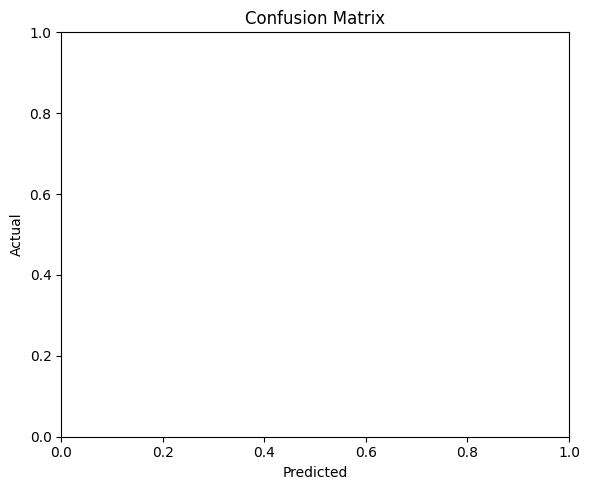

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the Logistic Regression model
# y_test: These are the actual true labels from your test dataset.
# y_pred: These are the predicted labels generated by your trained model (e.g., Logistic Regression).
# The confusion_matrix function outputs a 2x2 array (for binary classification)
# [[True Negatives (TN), False Positives (FP)],
#  [False Negatives (FN), True Positives (TP)]]
# External resource: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
cm = confusion_matrix(y_test, y_pred)

# Create a new figure to host the plot
# figsize=(width, height) in inches, controls the overall size of the plot.
plt.figure(figsize=(6, 5))

# Generate a heatmap using Seaborn to visualize the confusion matrix
# sns.heatmap: A powerful function to plot rectangular data as a color-encoded matrix.
#   cm: The 2x2 confusion matrix calculated above.
#   annot=True: If True, the data value in each cell will be written on the heatmap.
#   fmt='d': Specifies the format string for annotations, 'd' for integer decimal.
#   cmap='Blues': Sets the colormap. 'Blues' creates a gradient from light to dark blue,
#                 where darker shades typically indicate higher values, making it easy to see
#                 which cells have more counts (e.g., correct predictions).
#   xticklabels: Labels for the columns (predicted classes). 'Predicted 0' and 'Predicted 1'
#                usually correspond to the negative and positive classes, respectively.
#   yticklabels: Labels for the rows (actual classes). 'Actual 0' and 'Actual 1'
#                correspond to the true negative and true positive classes.
# External resource: https://seaborn.pydata.org/generated/seaborn.heatmap.html
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

# Set the title of the plot
plt.title('Confusion Matrix')

# Set the label for the Y-axis (Actual values)
plt.ylabel('Actual')

# Set the label for the X-axis (Predicted values)
plt.xlabel('Predicted')

# Adjust plot parameters for a tight layout, preventing labels from overlapping.
plt.tight_layout()

# Display the plot
plt.show()

## Resources

## Do-It-Yourself (DIY) ##

So far, we explored Logistic Regression. It assumes linear decision boundary and simple relationships.

But real-world data is often Non-linear, Noisy and Complex

This raises a question: Can we build better classifiers using other algorithms?

## Part - 2 (DIY) ##

Lets explore how we can implement the other ML Classification algorithms, namely

  1. K-Nearest Neighbors - https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
  2. Decision Tree Classifier - https://scikit-learn.org/stable/modules/tree.html
  3. Support Vector Machines - https://scikit-learn.org/stable/modules/svm.html




## Part - 2a : KNN ##

In [1]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the K-Nearest Neighbors (KNN) classifier.
# n_neighbors: The number of neighbors to use for classification. A common starting point is 5.
# Weights: 'uniform' (all points in neighborhood are weighted equally) or 'distance' (closer neighbors have more influence).
# Metric: 'minkowski' is the default (Euclidean distance when p=2).
knn = KNeighborsClassifier(n_neighbors=5)


## Resources

This section initializes the K-Nearest Neighbors (KNN) classifier.

*   **`from sklearn.neighbors import KNeighborsClassifier`**: Imports the KNN classifier from scikit-learn.
*   **`knn = KNeighborsClassifier(n_neighbors=5)`**:
    *   **Purpose**: Creates an instance of the `KNeighborsClassifier`.
    *   **`n_neighbors`**: This is the most important hyperparameter for KNN. It specifies the 'K' in K-Nearest Neighbors, meaning the number of neighbors to consider when making a prediction for a new data point. A common starting value is 5, but it should be tuned for optimal performance.
    *   **How KNN works**: For a new data point, KNN finds the `k` closest data points in the training set (based on a distance metric, typically Euclidean distance). The new data point is then assigned the class that is most common among its `k` nearest neighbors.

**Scikit-learn KNeighborsClassifier Documentation**: [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

**Understanding KNN**: [IBM - K-Nearest Neighbors (KNN)](https://www.ibm.com/topics/k-nearest-neighbors)

**Pictorial Representation**: [KNN Algorithm Visual](https://upload.wikimedia.org/wikipedia/commons/thumb/e/e7/KnnClassification.svg/640px-KnnClassification.svg.png)

In [2]:
# Train the KNN model on the scaled training data.
# The fit method learns the relationship between X_train and y_train.
# In KNN, 'fitting' involves storing the training data points.
knn.fit(X_train, y_train)

# Explanation: KNN is a non-parametric, lazy learning algorithm.
# It does not explicitly learn a model but memorizes the training dataset.
# Prediction is made by finding the K nearest data points in the training set
# to a new data point and assigning the majority class among them.


NameError: name 'X_train' is not defined

## Resources

This section trains and evaluates the K-Nearest Neighbors (KNN) model.

*   **`knn.fit(X_train, y_train)`**: Trains the KNN model.
    *   **Nature of KNN 'fit'**: Unlike many other algorithms that learn complex decision functions, KNN is a 'lazy learner'. The `fit` method primarily involves storing the training data (`X_train` and `y_train`). The actual 'learning' (finding neighbors) happens during prediction.
*   **`y_pred_knn = knn.predict(X_test)`**: Makes predictions on the unseen `X_test` data using the trained KNN model.
*   **Evaluation Metrics**: The subsequent `print` statements display the accuracy, confusion matrix, and classification report for the KNN model. These metrics (Accuracy, Precision, Recall, F1-score) are interpreted the same way as for Logistic Regression, allowing for a comparative analysis of model performance.

**Why is KNN a 'Lazy Learner'?**: [GeeksforGeeks - Lazy vs Eager Learning](https://www.geeksforgeeks.org/lazy-vs-eager-learning-in-machine-learning/)

**KNeighborsClassifier `fit` and `predict`**: [Scikit-learn KNN Methods](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier.fit)

In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict the classes for the test set using the trained KNN model.
y_pred_knn = knn.predict(X_test)

# Evaluate the KNN model's performance.
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Explanation of metrics:
# Accuracy: Proportion of correctly classified instances.
# Confusion Matrix: A table showing true positive, true negative, false positive, and false negative counts.
# Classification Report: Provides precision, recall, f1-score, and support for each class.
# Precision: The proportion of positive identifications that were actually correct (TP / (TP + FP)).
# Recall (Sensitivity): The proportion of actual positives that were identified correctly (TP / (TP + FN)).
# F1-score: The harmonic mean of precision and recall.


NameError: name 'X_test' is not defined

## Resources

This section visualizes the confusion matrix for the K-Nearest Neighbors (KNN) model.

*   **`cm_knn = confusion_matrix(y_test, y_pred_knn)`**: Calculates the confusion matrix specifically for the KNN model's predictions (`y_pred_knn`) against the actual test labels (`y_test`).
*   **`sns.heatmap(...)`**: Generates a heatmap similar to the Logistic Regression visualization.
    *   **`cmap='Blues'`**: Uses a blue colormap for this confusion matrix as well, which is a good default for sequential data like counts.
    *   **`xticklabels` / `yticklabels`**: Explicitly labeled for Benign (0) and Malignant (1) to enhance clarity specific to the breast cancer context.

**Interpretation of KNN Confusion Matrix**: Like before, we look for high values on the diagonal (correct predictions) and low values off the diagonal (errors). Comparing this heatmap with the Logistic Regression one can visually indicate which model performs better in terms of specific errors (False Positives vs. False Negatives).

**Improving KNN**: The 'Alternative Approaches/Optimizations for KNN' comments in the code provide excellent strategies for enhancing KNN performance, such as hyperparameter tuning (`n_neighbors`, `weights`), choosing appropriate distance metrics, dimensionality reduction, and ensuring data scaling. These are critical steps in a real-world machine learning pipeline.

**Hyperparameter Tuning Explained**: [Machine Learning Mastery - Hyperparameter Tuning](https://machinelearningmastery.com/hyperparameter-tuning-with-python-scikit-learn/)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title('KNN Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Alternative Approaches/Optimizations for KNN:
# 1. Hyperparameter Tuning: Use GridSearchCV or RandomizedSearchCV to find optimal 'n_neighbors' and 'weights'.
# 2. Distance Metric: Experiment with other metrics like 'manhattan' if data is not isotropic.
# 3. Dimensionality Reduction: Apply PCA or t-SNE before KNN if data has very high dimensions to reduce noise and improve efficiency.
# 4. Data Scaling: Ensure data is scaled (as done here with StandardScaler), as KNN is distance-based and sensitive to feature scales.


NameError: name 'y_test' is not defined

## Resources

## Part - 2b : Decision Tree Classifier ##

In [5]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier.
# random_state: Ensures reproducibility of the results.
# criterion: 'gini' for Gini impurity or 'entropy' for information gain.
# max_depth: Maximum depth of the tree to prevent overfitting. (Optional, can be tuned).
# min_samples_leaf: Minimum number of samples required to be at a leaf node.
dt = DecisionTreeClassifier(random_state=42)


## Resources

This section initializes the Decision Tree Classifier.

*   **`from sklearn.tree import DecisionTreeClassifier`**: Imports the Decision Tree classifier from scikit-learn.
*   **`dt = DecisionTreeClassifier(random_state=42)`**:
    *   **Purpose**: Creates an instance of the `DecisionTreeClassifier`.
    *   **`random_state=42`**: Ensures that the results are reproducible. Decision Trees involve some randomness in feature selection for splitting, so setting a `random_state` makes sure you get the same tree structure every time.
    *   **How Decision Trees work**: Decision Trees build a model in the form of a tree structure. It works by recursively splitting the dataset based on the feature that best separates the classes (e.g., using Gini impurity or Information Gain). Each internal node represents a feature test, each branch represents an outcome of the test, and each leaf node represents a class label.

**Scikit-learn DecisionTreeClassifier Documentation**: [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

**Understanding Decision Trees**: [Towards Data Science - Decision Tree Explained](https://towardsdatascience.com/decision-tree-algorithm-explained-83f12ecb8637)

**Pictorial Representation**: [Decision Tree Example](https://upload.wikimedia.org/wikipedia/commons/thumb/f/f3/Decision_tree_example_-_Entropy.svg/1200px-Decision_tree_example_-_Entropy.svg.png)

In [6]:
# Train the Decision Tree model on the scaled training data.
dt.fit(X_train, y_train)

# Explanation: A Decision Tree builds a classification model in the form of a tree structure.
# It breaks down a dataset into smaller and smaller subsets while at the same time an associated
# decision tree is incrementally developed. The final result is a tree with decision nodes and leaf nodes.
# Decision nodes split the data based on a feature, and leaf nodes represent the class labels.


NameError: name 'X_train' is not defined

## Resources

This section trains and evaluates the Decision Tree model.

*   **`dt.fit(X_train, y_train)`**: Trains the Decision Tree model.
    *   **Learning Process**: During fitting, the algorithm constructs the tree by finding the optimal splits at each node based on the training data. It aims to create branches that lead to the purest possible leaf nodes (i.e., leaf nodes that contain samples predominantly from one class).
*   **`y_pred_dt = dt.predict(X_test)`**: Makes predictions on the unseen `X_test` data using the trained Decision Tree model.
*   **Evaluation Metrics**: Similar to previous models, the accuracy, confusion matrix, and classification report are printed to assess the Decision Tree's performance. These metrics help determine how well the tree generalizes to new data and identifies specific types of errors.

**Decision Tree `fit` and `predict`**: [Scikit-learn Decision Tree Methods](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.fit)

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict the classes for the test set using the trained Decision Tree model.
y_pred_dt = dt.predict(X_test)

# Evaluate the Decision Tree model's performance.
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))


NameError: name 'X_test' is not defined

## Resources

This section visualizes the confusion matrix for the Decision Tree model.

*   **`cm_dt = confusion_matrix(y_test, y_pred_dt)`**: Calculates the confusion matrix for the Decision Tree model's predictions (`y_pred_dt`).
*   **`sns.heatmap(...)`**: Generates a heatmap visualization.
    *   **`cmap='Greens'`**: Uses a green colormap, providing a distinct visual for the Decision Tree results compared to the previous models.

**Interpretation of Decision Tree Confusion Matrix**: The interpretation is consistent: higher values on the diagonal indicate better performance. Observing the counts of True Positives, True Negatives, False Positives, and False Negatives helps in understanding where the Decision Tree excels or struggles.

**Improving Decision Trees**: The 'Alternative Approaches/Optimizations for Decision Trees' comments in the code highlight common strategies:
    1.  **Hyperparameter Tuning**: Adjusting parameters like `max_depth`, `min_samples_split`, `min_samples_leaf`, and `criterion` is crucial to prevent overfitting and improve generalization.
    2.  **Ensemble Methods**: Techniques like Random Forests and Gradient Boosting (e.g., AdaBoost, XGBoost) combine multiple decision trees to create more robust and accurate models, often mitigating the instability of a single decision tree.
    3.  **Feature Importance**: Decision Trees can provide insights into which features are most influential in making predictions, which can be valuable for feature selection and domain understanding.
    4.  **Pruning**: Methods to reduce the complexity of the tree, thereby reducing overfitting, such as `ccp_alpha` (Cost-Complexity Pruning) in scikit-learn.

**Ensemble Methods Explained**: [GeeksforGeeks - Ensemble Learning](https://www.geeksforgeeks.org/ensemble-learning-in-machine-learning/)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Alternative Approaches/Optimizations for Decision Trees:
# 1. Hyperparameter Tuning: Tune 'max_depth', 'min_samples_split', 'min_samples_leaf', 'criterion' using GridSearchCV.
# 2. Ensemble Methods: Use RandomForestClassifier or GradientBoostingClassifier (e.g., AdaBoost, XGBoost, LightGBM)
#    which combine multiple decision trees to improve robustness and reduce overfitting.
# 3. Feature Importance: Analyze feature importance from the trained tree to identify most relevant features.
# 4. Pruning: Techniques like cost-complexity pruning (ccp_alpha parameter) can simplify the tree and prevent overfitting.


NameError: name 'y_test' is not defined

## Resources

## Part - 2c : SVM ##

In [9]:
from sklearn.svm import SVC

# Initialize the Support Vector Machine (SVM) classifier.
# kernel: Specifies the kernel type to be used in the algorithm. 'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'.
#   'linear': Suitable for linearly separable data.
#   'rbf' (Radial Basis Function): A popular choice for non-linear decision boundaries.
# C: Regularization parameter. The strength of the regularization is inversely proportional to C.
# random_state: Ensures reproducibility when using 'rbf' kernel due to internal random processes.
svm = SVC(kernel='linear', random_state=42)


## Resources

This section initializes the Support Vector Machine (SVM) classifier.

*   **`from sklearn.svm import SVC`**: Imports the Support Vector Classifier (`SVC`) from scikit-learn. `SVC` is suitable for classification tasks.
*   **`svm = SVC(kernel='linear', random_state=42)`**:
    *   **Purpose**: Creates an instance of the `SVC` model.
    *   **`kernel='linear'`**: This is a crucial hyperparameter that defines the type of hyperplane used to separate the data.
        *   **'linear'**: Suitable for datasets where classes can be separated by a straight line (or a hyperplane in higher dimensions). It's computationally faster for large datasets if linear separability is assumed.
        *   **Other common kernels**: `'rbf'` (Radial Basis Function) is very popular for non-linearly separable data, as it implicitly maps data into a higher-dimensional space.
    *   **`random_state=42`**: Ensures reproducibility, especially when using certain kernels or during internal shuffling processes.
    *   **How SVM works**: SVM aims to find the optimal hyperplane that best separates different classes in the feature space. The 'optimal' hyperplane is the one that maximizes the margin (the distance between the hyperplane and the nearest data points from each class, called support vectors).

**Scikit-learn SVC Documentation**: [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

**Understanding SVM**: [Towards Data Science - Support Vector Machines Explained](https://towardsdatascience.com/support-vector-machines-svm-a-complete-tutorial-from-scratch-in-python-69e0210bc9c4)

**Pictorial Representation**: [SVM Hyperplane and Margins](https://upload.wikimedia.org/wikipedia/commons/thumb/7/72/SVM_separation_of_two_classes_with_a_hyperplane.svg/1200px-SVM_separation_of_two_classes_with_a_hyperplane.svg.png)

In [10]:
# Train the SVM model on the scaled training data.
svm.fit(X_train, y_train)

# Explanation: SVM works by finding the optimal hyperplane that best separates the data points
# of different classes in the feature space. The hyperplane is chosen to maximize the margin
# between the two classes. For non-linear data, SVM uses the 'kernel trick' to implicitly map
# the input into a high-dimensional feature space where a linear separation is possible.


NameError: name 'X_train' is not defined

## Resources

This section trains and evaluates the Support Vector Machine (SVM) model.

*   **`svm.fit(X_train, y_train)`**: Trains the SVM model.
    *   **Learning Process**: During fitting, the SVM algorithm identifies the support vectors and constructs the optimal hyperplane (or decision boundary) that best separates the training data points into their respective classes while maximizing the margin.
*   **`y_pred_svm = svm.predict(X_test)`**: Makes predictions on the unseen `X_test` data using the trained SVM model.
*   **Evaluation Metrics**: The accuracy, confusion matrix, and classification report are printed to assess the SVM's performance. These metrics help in understanding the model's generalization capabilities and pinpointing specific types of classification errors.

**SVM `fit` and `predict`**: [Scikit-learn SVM Methods](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.fit)

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict the classes for the test set using the trained SVM model.
y_pred_svm = svm.predict(X_test)

# Evaluate the SVM model's performance.
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))


NameError: name 'X_test' is not defined

## Resources

This section visualizes the confusion matrix for the Support Vector Machine (SVM) model.

*   **`cm_svm = confusion_matrix(y_test, y_pred_svm)`**: Calculates the confusion matrix for the SVM model's predictions (`y_pred_svm`).
*   **`sns.heatmap(...)`**: Generates a heatmap visualization.
    *   **`cmap='Purples'`**: Uses a purple colormap for this confusion matrix, offering a distinct visual theme for the SVM results.

**Interpretation of SVM Confusion Matrix**: The interpretation follows the same principles: prioritize high values on the diagonal and low values off-diagonal. This visualization helps in comparing the SVM's performance visually against other models.

**Improving SVM**: The 'Alternative Approaches/Optimizations for SVM' comments in the code provide comprehensive guidance:
    1.  **Hyperparameter Tuning**: Optimizing the `C` parameter (regularization) and the `kernel` type (`linear`, `rbf`, `poly`) is crucial for SVM. `GridSearchCV` or `RandomizedSearchCV` are commonly used.
    2.  **Kernel Choice**: The choice of kernel is often dataset-dependent. For non-linear relationships, the `'rbf'` kernel is a robust choice, though it can be more computationally intensive than `'linear'` for very large datasets.
    3.  **Scaling**: SVM is highly sensitive to feature scaling because it relies on distance calculations. Ensuring features are scaled (as done with `StandardScaler`) is paramount for good performance.
    4.  **Alternative Implementations**: For specific scenarios, such as very large datasets with linear separability, `LinearSVC` (a scikit-learn class optimized for linear SVMs) can be more efficient than `SVC` with a linear kernel.

**SVM Kernel Trick**: [GeeksforGeeks - Kernel Trick](https://www.geeksforgeeks.org/kernel-trick-svm/)

**SVM Hyperparameter Tuning**: [Scikit-learn - SVM Hyperparameters](https://scikit-learn.org/stable/modules/svm.html#svm-tips-and-tricks)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Benign (0)', 'Predicted Malignant (1)'],
            yticklabels=['Actual Benign (0)', 'Actual Malignant (1)'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Alternative Approaches/Optimizations for SVM:
# 1. Hyperparameter Tuning: Optimize 'C' (regularization parameter) and 'kernel' (e.g., 'rbf', 'poly')
#    parameters using GridSearchCV or RandomizedSearchCV.
# 2. Kernel Choice: Experiment with different kernel functions ('linear', 'rbf', 'poly') based on data characteristics.
#    'rbf' is often a good general-purpose choice but computationally more intensive than 'linear' for very large datasets.
# 3. Scaling: SVM is highly sensitive to feature scaling, so it's crucial to scale data (as done here).
# 4. Alternative Implementations: For very large datasets, consider `LinearSVC` from `sklearn.svm` which is optimized for linear kernels and large-scale classification.


NameError: name 'y_test' is not defined

## Resources